## 7.17 분자 최적화를 위한 양자 경사하강(QGD)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, partial_trace
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_qsphere, plot_state_city, plot_state_hinton

# 인라인 플롯
%matplotlib inline

In [3]:
# 시뮬레이터 정의
simulator = AerSimulator()

In [4]:
# 분자계용 양자회로 정의
def create_circuit(theta1, theta2):
    qc = QuantumCircuit(2)
    # theta 매개변수로 게이트 적용
    qc.rx(theta1, 0)
    qc.ry(theta2, 1)
    # 큐비트 얽힘
    qc.cx(0, 1)
    return qc

In [5]:
# 비용 함수 정의 (예: 분자 에너지)
def cost_function(theta1, theta2):
    return np.sin(theta1)**2 + np.cos(theta2)**2  # 예시 비용 함수

In [6]:
# 기울기 계산 정의
def compute_gradient(theta1, theta2):
    grad_theta1 = 2 * np.sin(theta1) * np.cos(theta1)  # theta1에 대한 기울기
    grad_theta2 = -2 * np.sin(theta2) * np.cos(theta2)  # theta2에 대한 기울기
    return grad_theta1, grad_theta2

In [7]:
# 매개변수 초기화
theta1_val = np.random.random()  # theta1 무작위 초기화
theta2_val = np.random.random()  # theta2 무작위 초기화
eta = 0.1  # 학습률
num_steps = 20  # 경사하강 스텝 수

In [8]:
energy_convergence = []  # 시각화를 위한 에너지 값 저장
state_list = []  # 최종 시각화를 위한 상태 저장

In [9]:
# 분자 최적화를 위한 경사하강 수행
for step in range(num_steps):
    # 양자회로 생성 및 트랜스파일
    qc = create_circuit(theta1_val, theta2_val)
    transpiled_qc = transpile(qc, simulator)

    transpiled_qc.save_statevector()
    # 회로를 시뮬레이션해 상태벡터 획득
    # 실행 전 θ1, θ2 파라미터 결합
    param_bindings = {qc.parameters[0]: theta1_val, qc.parameters[1]: theta2_val} if qc.parameters else {}
    job = simulator.run(transpiled_qc, parameter_binds=[param_bindings])

    # 상태벡터 결과 획득
    result = job.result()
    state = Statevector(result.get_statevector())  # 결과에서 상태벡터 회수

    # 루프 후 시각화를 위해 상태 저장
    state_list.append(state)

    # 현재 에너지(비용 함수) 계산
    energy = cost_function(theta1_val, theta2_val)
    energy_convergence.append(energy)  # 플롯을 위해 에너지 저장
    print(f"스텝 {step + 1}: 에너지 = {energy:.4f}, θ1 = {theta1_val:.4f}, θ2 = {theta2_val:.4f}")

    # 비용 함수의 기울기 계산
    grad_theta1, grad_theta2 = compute_gradient(theta1_val, theta2_val)

    # 경사하강으로 매개변수 갱신
    theta1_val -= eta * grad_theta1
    theta2_val -= eta * grad_theta2

스텝 1: 에너지 = 1.6445, θ1 = 0.9629, θ2 = 0.1719
스텝 2: 에너지 = 1.5417, θ1 = 0.8691, θ2 = 0.2056
스텝 3: 에너지 = 1.4260, θ1 = 0.7705, θ2 = 0.2455
스텝 4: 에너지 = 1.3029, θ1 = 0.6706, θ2 = 0.2927
스텝 5: 에너지 = 1.1778, θ1 = 0.5732, θ2 = 0.3479
스텝 6: 에너지 = 1.0545, θ1 = 0.4821, θ2 = 0.4121
스텝 7: 에너지 = 0.9339, θ1 = 0.3999, θ2 = 0.4854
스텝 8: 에너지 = 0.8145, θ1 = 0.3282, θ2 = 0.5680
스텝 9: 에너지 = 0.6951, θ1 = 0.2672, θ2 = 0.6587
스텝 10: 에너지 = 0.5759, θ1 = 0.2162, θ2 = 0.7555
스텝 11: 에너지 = 0.4604, θ1 = 0.1743, θ2 = 0.8553
스텝 12: 에너지 = 0.3538, θ1 = 0.1402, θ2 = 0.9543
스텝 13: 에너지 = 0.2613, θ1 = 0.1125, θ2 = 1.0487
스텝 14: 에너지 = 0.1862, θ1 = 0.0902, θ2 = 1.1351
스텝 15: 에너지 = 0.1287, θ1 = 0.0722, θ2 = 1.2116
스텝 16: 에너지 = 0.0869, θ1 = 0.0578, θ2 = 1.2775
스텝 17: 에너지 = 0.0577, θ1 = 0.0463, θ2 = 1.3328
스텝 18: 에너지 = 0.0378, θ1 = 0.0371, θ2 = 1.3786
스텝 19: 에너지 = 0.0246, θ1 = 0.0297, θ2 = 1.4161
스텝 20: 에너지 = 0.0159, θ1 = 0.0237, θ2 = 1.4466


스텝 6: 에너지 = 0.9097, θ1 = 0.0289, θ2 = 0.3066
스텝 7: 에너지 = 0.8737, θ1 = 0.0231, θ2 = 0.3642
스텝 8: 에너지 = 0.8260, θ1 = 0.0185, θ2 = 0.4308
스텝 9: 에너지 = 0.7648, θ1 = 0.0148, θ2 = 0.5066
스텝 10: 에너지 = 0.6892, θ1 = 0.0119, θ2 = 0.5915


스텝 11: 에너지 = 0.6007, θ1 = 0.0095, θ2 = 0.6841
스텝 12: 에너지 = 0.5034, θ1 = 0.0076, θ2 = 0.7820
스텝 13: 에너지 = 0.4040, θ1 = 0.0061, θ2 = 0.8820
스텝 14: 에너지 = 0.3101, θ1 = 0.0049, θ2 = 0.9802
스텝 15: 에너지 = 0.2283, θ1 = 0.0039, θ2 = 1.0727


스텝 16: 에너지 = 0.1620, θ1 = 0.0031, θ2 = 1.1566
스텝 17: 에너지 = 0.1115, θ1 = 0.0025, θ2 = 1.2303
스텝 18: 에너지 = 0.0751, θ1 = 0.0020, θ2 = 1.2933
스텝 19: 에너지 = 0.0497, θ1 = 0.0016, θ2 = 1.3460
스텝 20: 에너지 = 0.0325, θ1 = 0.0013, θ2 = 1.3894


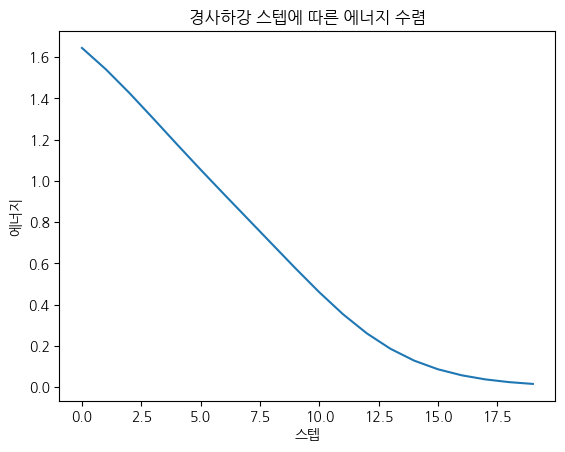

In [10]:
# 시각화: 에너지 수렴 플롯
plt.plot(energy_convergence)
plt.title('경사하강 스텝에 따른 에너지 수렴')
plt.xlabel('스텝')
plt.ylabel('에너지')
plt.show()

In [11]:
# 마지막 상태 시각화
final_state = state_list[-1]  # 루프의 마지막 상태

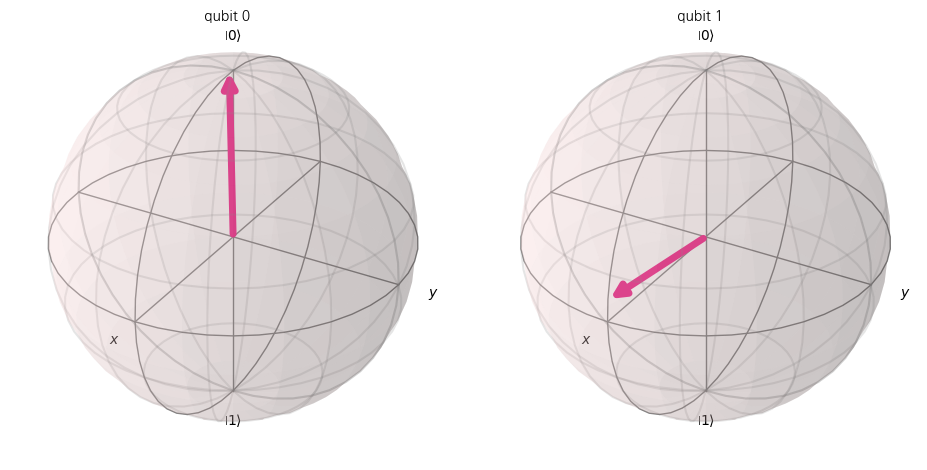

In [12]:
# 시각화: 블로흐 다중벡터
plot_bloch_multivector(final_state)
plt.show()

/opt/miniconda3/envs/qml/lib/python3.10/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))


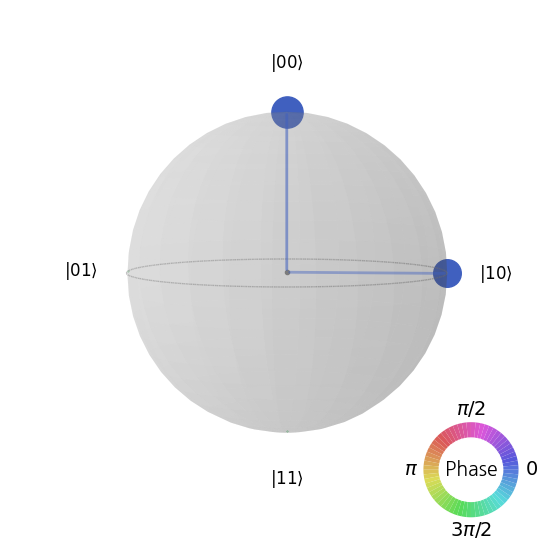

In [13]:
# 시각화: QSphere
plot_state_qsphere(final_state)
plt.show()

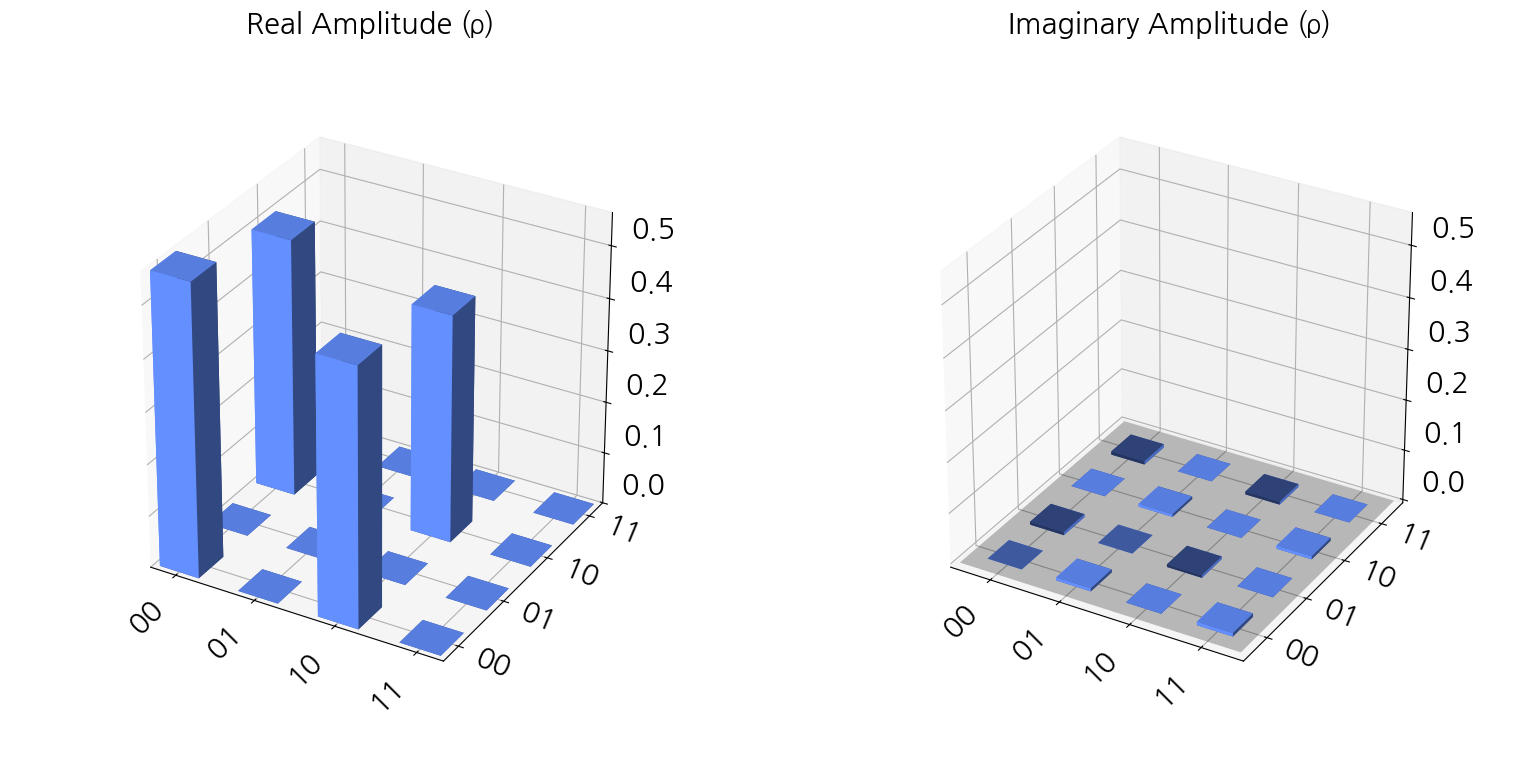

In [14]:
# 시각화: State City 플롯
plot_state_city(final_state)
plt.show()

In [15]:
# # 시각화: 부분 대각합 플롯 (축소 밀도행렬)
# rho = partial_trace(final_state, [1])
# plot_state_hinton(rho)
# plt.show()

In [16]:
# 측정이 있는 회로의 최종 실행
final_qc = create_circuit(theta1_val, theta2_val)
final_qc.measure_all()  # 모든 큐비트에 측정 추가
measured_qc = transpile(final_qc, simulator)

In [17]:
# 측정이 있는 회로 실행
measured_job = simulator.run(measured_qc)
measured_result = measured_job.result()

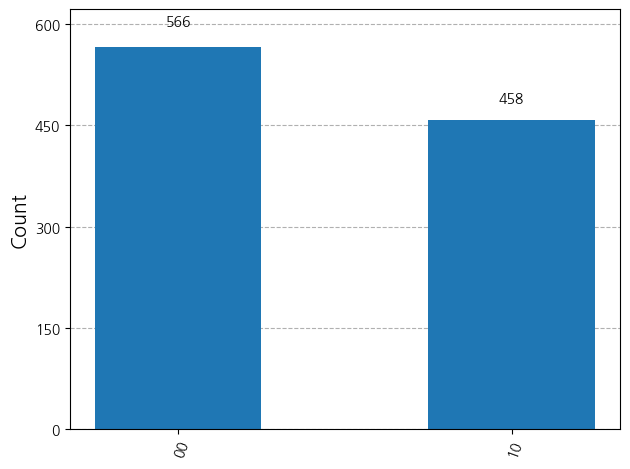

In [18]:
# 카운트 획득 및 시각화 (히스토그램)
counts = measured_result.get_counts()
plot_histogram(counts)
plt.show()